In [2]:
import pandas as pd
import seaborn as sns

In [3]:
insurance_data=pd.read_csv("insurance.csv")

mean squared error for alpha=0.001: 33596918.49260664
mean squared error for alpha=0.1: 33597180.375486486
mean squared error for alpha=1: 33605932.26390232
mean squared error for alpha=2: 33615034.16817719
mean squared error for alpha=5: 33641228.01264165
mean squared error for alpha=10: 33681318.78237888
mean squared error for alpha=20: 33764201.88887349
mean squared error for alpha=30: 33851777.379185945
mean squared error for alpha=40: 33904639.05547671
mean squared error for alpha=50: 33950393.34079369
mean squared error for alpha=100: 34215583.12377537


<Axes: >

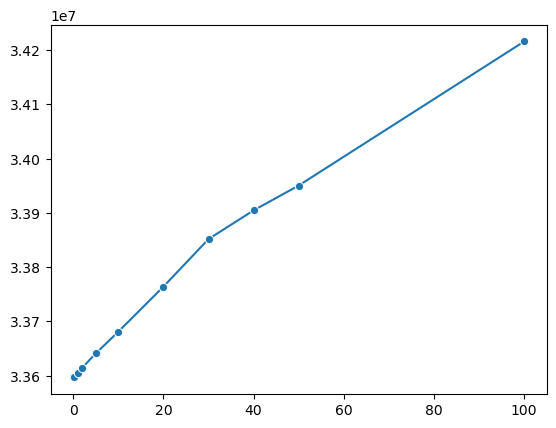

In [13]:
#ONE HOT ENCODING
from sklearn.metrics import r2_score

X=insurance_data.drop(columns=["charges"], axis=1)
y=insurance_data["charges"]

X=pd.get_dummies(X, columns=["region"], drop_first=False, dtype=int)

X["sex"]=X["sex"].map({"male": 1, "female":0})
X["smoker"]=X["smoker"].map({"yes": 1, "no":0})

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
alphas=[0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

mses=[]

for a in alphas:
    Lasso_model=Lasso(alpha=a)
    Lasso_model.fit(X_train, y_train)
    y_pred=Lasso_model.predict(X_test)

    MSE=mean_squared_error(y_test, y_pred)
    print(f"mean squared error for alpha={a}:", MSE)
    mses.append(MSE)

sns.lineplot(x=alphas, y=mses, marker="o")

In [14]:
#using LassoCV

from sklearn.linear_model import LassoCV, ElasticNet
a=[0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

Lasso_CV_model=LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)

Lasso_CV_model.fit(X_train, y_train)

print("best alpha value:", Lasso_CV_model.alpha_)

y_pred=Lasso_CV_model.predict(X_test)

mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print("mse:", mse)
print("r2_score", r2)

best alpha value: 100.0
mse: 34215583.12377537
r2_score 0.7796079697721174
